# Pre-lab 2 — A Gaussian Process and the Class GP Design — SOLUTION KEY
### ME 323 Module 1 (staff only)

**The equation beam has been tested.** The class design from Pre-lab 1,
(b = 1.25, H_web = 13.4), predicted at 46.6 N/g, carried
**470.4 N — 36.66 N/g**. Strong (second-best beam ever tested), but 21%
short of what the calibrated equations promised. The equations have one story
per failure mode; the printer has more stories than that.

Here you fit a model that assumes *nothing* about failure modes: a Gaussian
Process on the data alone. It returns a prediction **and an uncertainty**
everywhere. You will fit it, read its maps, code two acquisition functions,
and produce the **class GP design** — the second and last beam staff test for
everyone.

*(Fill-ins marked as before; checkpoints tell you what you should arrive at.)*

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
CS = 1.0                          # web shear-strength multiplier    (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_g"] = mass_g(df.b, df.H)
print(len(df), "tested beams")

# append the tested class equation beam — it is data now
eq_beam = pd.DataFrame([dict(beam_id=15, b=1.25, H=13.4, strength_N=470.4,
                             mass_g=mass_g(1.25, 13.4))])
df = pd.concat([df, eq_beam], ignore_index=True)
df["str_to_weight"] = df.strength_N / df.mass_g
print(len(df), "beams (14 + the class equation beam)")

loaded from GitHub
14 tested beams
15 beams (14 + the class equation beam)


## 1. Fit the GP

Inputs (b, H_web), z-scored. Target: **log** strength-to-weight (so the noise
is relative). Assumed measurement noise: **3%** (`alpha = 0.03**2`) — three
early repeat prints of one design spread about that much; treat it as an
assumption, not a fact. Kernel and settings are fixed so the class GP is the
same for everyone.

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF

X = df[["b", "H"]].values
fmu, fsd = X.mean(0), X.std(0) + 1e-12
y = np.log(df.str_to_weight.values)
ymean = y.mean()

kernel = C(1.0, (1e-3, 1e3)) * RBF([1.0, 1.0], (1e-1, 30.0))
gp = GaussianProcessRegressor(kernel, alpha=0.03**2, normalize_y=False,
                              n_restarts_optimizer=5, random_state=0)
gp.fit((X - fmu)/fsd, y - ymean)
print("fitted kernel:", gp.kernel_)
print("(checkpoint: roughly 0.0773**2 * RBF(length_scale=[1.99, 0.128]))")

fitted kernel: 0.0773**2 * RBF(length_scale=[1.99, 0.128])
(checkpoint: roughly 0.0773**2 * RBF(length_scale=[1.99, 0.128]))


## 2. The two maps

Mean (best guess) and standard deviation (how unsure). The GP is unsure where
there is no data — look at where your 15 beams are NOT.

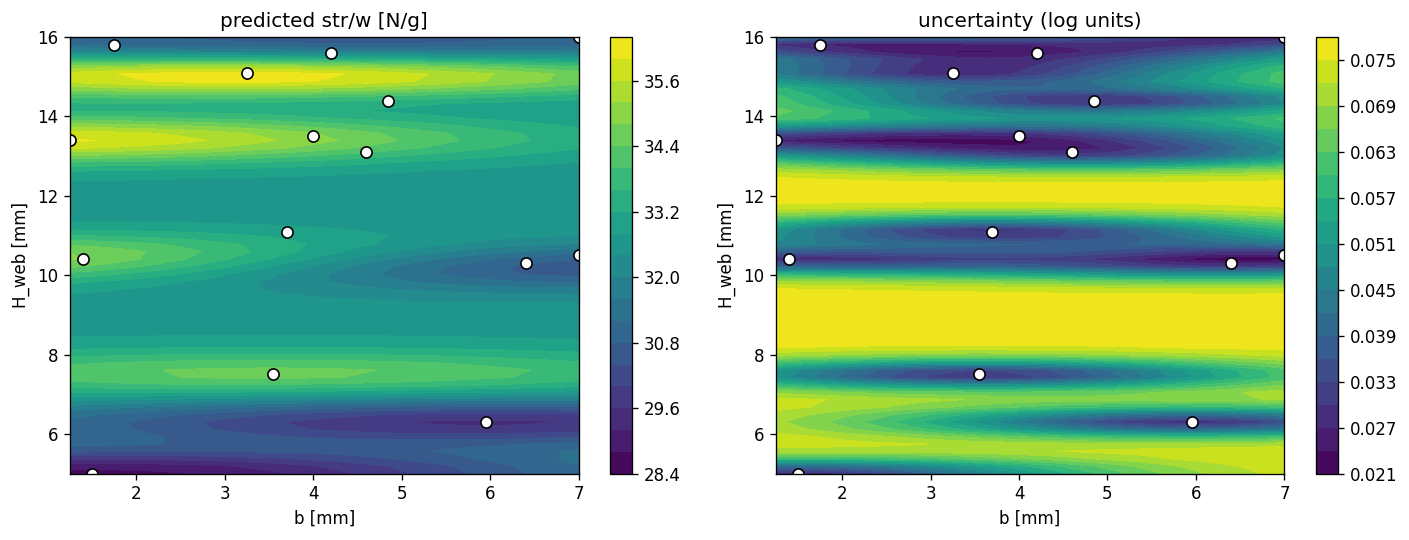

In [3]:
bg = np.linspace(1.25, 7.0, 60); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)
Xg = np.column_stack([BB.ravel(), HH.ravel()])
mu_c, std = gp.predict((Xg - fmu)/fsd, return_std=True)
MU = np.exp(mu_c + ymean).reshape(BB.shape)
STD = std.reshape(BB.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, Z, t in [(ax[0], MU, "predicted str/w [N/g]"), (ax[1], STD, "uncertainty (log units)")]:
    cf = a.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=a)
    a.scatter(df.b, df.H, c="w", edgecolor="k", s=45)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(t)
plt.tight_layout(); plt.show()

## 3. Acquisition: explore vs exploit

**Maximum Upper Interval:** $a(x) = \mu(x) + \psi\,\sigma(x)$.
Small ψ trusts the mean (exploit); large ψ chases uncertainty (explore).
**FILL IN** the MUI line.

In [4]:
def mui(mu, sigma, psi):
    return mu + psi*sigma

def recommend_mui(psi):
    i = np.argmax(mui(mu_c, std, psi))
    return Xg[i], np.exp(mu_c[i] + ymean), std[i]

for psi in [0.0, 1.0, 3.0]:
    x, m, s = recommend_mui(psi)
    print(f"psi={psi}:  b={x[0]:.2f}, H_web={x[1]:.2f}   pred {m:.1f} N/g,  sigma {s:.3f}")
print("\nCHECKPOINT (psi=1.0): you should arrive at b = 1.74, H_web = 14.88, "
      "pred 35.9 N/g.")
print("If you are not getting that, check your work or talk to a TA.")

psi=0.0:  b=3.10, H_web=15.07   pred 36.2 N/g,  sigma 0.028
psi=1.0:  b=1.74, H_web=14.88   pred 35.9 N/g,  sigma 0.046
psi=3.0:  b=7.00, H_web=15.07   pred 34.6 N/g,  sigma 0.061

CHECKPOINT (psi=1.0): you should arrive at b = 1.74, H_web = 14.88, pred 35.9 N/g.
If you are not getting that, check your work or talk to a TA.


## 4. The noise assumption is a dial, not a fact

Refit at 1%, 3%, and 10% assumed noise and watch the ψ=1 recommendation.

In [5]:
for pct in [1, 3, 10]:
    g2 = GaussianProcessRegressor(kernel, alpha=(pct/100)**2, normalize_y=False,
                                  n_restarts_optimizer=5, random_state=0).fit((X-fmu)/fsd, y-ymean)
    m2, s2 = g2.predict((Xg-fmu)/fsd, return_std=True)
    i = np.argmax(m2 + 1.0*s2)
    print(f"assumed noise {pct:>2}%:  b={Xg[i,0]:.2f}, H_web={Xg[i,1]:.2f},  "
          f"pred {np.exp(m2[i]+ymean):.1f} N/g")
print("\nCHECKPOINT: the recommendation should move as the assumed noise grows: 1% -> (1.54, 14.88);  3% -> (1.74, 14.88);  10% -> (1.35, 13.58)")

assumed noise  1%:  b=1.54, H_web=14.88,  pred 36.4 N/g
assumed noise  3%:  b=1.74, H_web=14.88,  pred 35.9 N/g


assumed noise 10%:  b=1.35, H_web=13.58,  pred 33.3 N/g

CHECKPOINT: the recommendation should move as the assumed noise grows: 1% -> (1.54, 14.88);  3% -> (1.74, 14.88);  10% -> (1.35, 13.58)


**For your memo.** There is no single correct noise value. If the
recommendation moves when the assumption moves, what does that say about how
much weight the recommendation deserves?

## 5. Expected Improvement

EI weighs how much a new test might beat the best beam so far. **FILL IN** the
improvement term.

In [6]:
from scipy.stats import norm
y_best = np.log(df.str_to_weight).max() - ymean
def ei(mu, sigma, xi=0.0):
    imp = mu - y_best - xi
    Z = np.where(sigma > 1e-9, imp/np.maximum(sigma, 1e-9), 0.0)
    return np.where(sigma > 1e-9, imp*norm.cdf(Z) + sigma*norm.pdf(Z), 0.0)

iE = np.argmax(ei(mu_c, std, xi=0.01))
print(f"EI (xi=0.01) recommends:  b={Xg[iE,0]:.2f}, H_web={Xg[iE,1]:.2f}, "
      f"pred {np.exp(mu_c[iE]+ymean):.1f} N/g")
print("\nCHECKPOINT: you should arrive at b = 1.25, H_web = 14.88.")

EI (xi=0.01) recommends:  b=1.25, H_web=14.88, pred 35.7 N/g

CHECKPOINT: you should arrive at b = 1.25, H_web = 14.88.


## 6. The class GP design

The class rule is **MUI with ψ = 1.0 at 3% noise**, so every group nominates
the same beam: **(b = 1.74, H_web = 14.88)** — your section-3 checkpoint.
Staff print and test it; the result is revealed in Submission 1.

## Memo questions

1. The equations gave one number; the GP gives a mean *and* an uncertainty.
   Point to one place on the maps where the extra information would change
   what you do.
2. Compare the GP design to the equation design from Pre-lab 1. What is each
   one optimizing for, and why did they land in different places?
3. The GP knows nothing about failure modes, yet it was handed the fracture
   notes in the data table. Name one thing the notes tell you that neither
   model uses — yet.